# Dataset Modeling

1. Get the ACOD-12K Dataset

In [1]:
import numpy as np
import os
import test_utils as utils

In [2]:
import pandas as pd

# Read acod_eval_averages.csv
df1 = pd.read_csv("Results/ClassCharacteristics1_B3.csv")
df2 = pd.read_csv("Results/ClassCharacteristics2_B3.csv")
df3 = pd.read_csv("Results/ClassCharacteristics3_B3.csv")

In [3]:
#class_instances_df = pd.read_csv("Results/ClassCharacteristics.csv")
class_instances_df = pd.concat([df1, df2, df3], ignore_index=True)

In [4]:
df1.head(5)

,crop,filename,instance,area,pixels,buffer_pixels
0,bean,bean_left_00001.png,1,2251,"[[102, 139, 106], [89, 117, 91], [91, 116, 91]...","[[127, 145, 118], [120, 140, 110], [112, 130, ..."
1,bean,bean_left_00001.png,2,2309,"[[159, 203, 163], [164, 211, 172], [167, 214, ...","[[162, 190, 145], [160, 190, 144], [167, 193, ..."
2,bean,bean_left_00001.png,3,3180,"[[158, 186, 146], [181, 208, 168], [153, 178, ...","[[157, 193, 153], [168, 204, 164], [164, 199, ..."
3,bean,bean_left_00001.png,4,2194,"[[169, 188, 153], [167, 187, 152], [175, 196, ...","[[135, 155, 126], [138, 158, 129], [147, 167, ..."
4,bean,bean_left_00002.png,1,1615,"[[100, 134, 99], [106, 140, 105], [105, 126, 1...","[[101, 122, 90], [96, 120, 87], [97, 120, 91],..."


In [6]:
from numpy import uint8
import os

output_dir = "plant_csv_outputs/B3"
os.makedirs(output_dir, exist_ok=True)

plants=["bean", "cucumber", "kiwi", "loquat", "peach", "pepper", "plum", "tomato", "watermelon", "zucchini"]

# Dictionary to store mean colors per plant
plant_mean_colors = {}
plant_mean_buffer_colors = {}
plant_std_colors = {}
plant_std_buffer_colors = {}
plant_diff_colors = {}

plant_mean_instance_size = {}
plant_std_instance_size = {}

plant_mean_instance_per_image = {}
plant_std_instance_per_image = {}
for plant in plants:
    # Select rows corresponding to this plant
    plant_rows = class_instances_df[class_instances_df["crop"] == plant]

    #Group by filename
    filenames_counts = plant_rows.groupby(["filename"]).size().to_list()
    print(filenames_counts)
    
    #Actual pixels across all instances of that plant
    all_pixels = []
    buffer_all_pixels = []

    #Number of pixels in each instance here
    pixel_sizes = [] 
    
    for idx, row in plant_rows.iterrows():
        # Convert string back to list of pixels
        pixels = np.array(eval(row["pixels"]))  # shape: (num_pixels, 3)
        buffer_pixels = np.array(eval(row["buffer_pixels"]))
        if len(pixels) > 0 and len(buffer_pixels) > 0:
            pixel_sizes.append(len(pixels))
            all_pixels.append(pixels)
            buffer_all_pixels.append(buffer_pixels)     
    print(pixel_sizes)
    if len(all_pixels) > 0 and len(buffer_all_pixels) > 0:
        # Stack all pixels for this plant
        all_pixels = np.vstack(all_pixels)
        buffer_all_pixels = np.vstack(buffer_all_pixels)

        # 🔽 SAVE CSV FILES

        # all_pixels (RGB columns)
        pd.DataFrame(all_pixels, columns=["B", "G", "R"]).to_csv(
            f"{output_dir}/{plant}_all_pixels.csv", index=False
        )

        # buffer pixels
        pd.DataFrame(buffer_all_pixels, columns=["B", "G", "R"]).to_csv(
            f"{output_dir}/{plant}_buffer_all_pixels.csv", index=False
        )

        # pixel sizes
        pd.DataFrame(pixel_sizes, columns=["pixel_size"]).to_csv(
            f"{output_dir}/{plant}_pixel_sizes.csv", index=False
        )

        # filenames counts
        pd.DataFrame(filenames_counts, columns=["instances_per_image"]).to_csv(
            f"{output_dir}/{plant}_filenames_counts.csv", index=False
        )

        mean_color = np.mean(all_pixels, axis=0)  # mean BGR across all pixels
        mean_buffer_color = np.mean(buffer_all_pixels, axis=0)

        std_color = np.std(all_pixels, axis=0)  # STD BGR across all pixels
        std_buffer_color = np.std(buffer_all_pixels, axis=0)

        mean_sizes = np.mean(pixel_sizes, axis=0)
        std_sizes = np.std(pixel_sizes, axis=0)

        mean_inst_count = np.mean(filenames_counts, axis=0)
        std_inst_count = np.std(filenames_counts, axis=0)

        #BGR to RGB
        mean_color = mean_color[::-1]
        mean_buffer_color = mean_buffer_color[::-1]
        std_color = std_color[::-1]
        std_buffer_color = std_buffer_color[::-1]

        plant_mean_colors[plant] = mean_color.astype(int)
        plant_mean_buffer_colors[plant] = mean_buffer_color.astype(int)
        plant_std_colors[plant] = std_color.astype(int)
        plant_std_buffer_colors[plant] = std_buffer_color.astype(int)
        plant_diff_colors[plant] = np.linalg.norm(all_pixels-buffer_all_pixels, axis=1).astype(int)
        plant_mean_instance_size[plant] = mean_sizes.astype(int)
        plant_std_instance_size[plant] = std_sizes.astype(int)
        plant_mean_instance_per_image[plant] = mean_inst_count.astype(int)
        plant_std_instance_per_image[plant] = std_inst_count.astype(int)
    else:
        plant_mean_colors[plant] = np.array([0, 0, 0])
        plant_mean_buffer_colors[plant] = np.array([0, 0, 0])
        plant_std_colors[plant] = np.array([0, 0, 0])
        plant_std_buffer_colors[plant] = np.array([0, 0, 0])
        plant_diff_colors[plant] = 0
        plant_mean_instance_size[plant] = 0
        plant_std_instance_size[plant] = 0
        plant_mean_instance_per_image[plant] = 0
        plant_std_instance_per_image[plant] = 0

# Print results
for plant in plants:
    print("=====================================")
    print(f"{plant}: Mean RGB = {plant_mean_colors[plant]}")
    print(f"{plant}: STD RGB = {plant_std_colors[plant]}")
    print(f"{plant}: Mean Buffer RGB = {plant_mean_buffer_colors[plant]}")
    print(f"{plant}: STD Buffer RGB = {plant_std_buffer_colors[plant]}")
    print(f"{plant}: Color-Buffer Difference = {plant_diff_colors[plant]}")
    print(f"{plant}: Mean Instance Size = {plant_mean_instance_size[plant]}")
    print(f"{plant}: STD Instance Size = {plant_std_instance_size[plant]}")
    print(f"{plant}: Mean Instances Per Image = {plant_mean_instance_per_image[plant]}")
    print(f"{plant}: STD Instances Per Image = {plant_std_instance_per_image[plant]}")
    print("=====================================")
    print()


[4, 4, 4, 4, 1, 5, 9, 9, 2, 6, 3, 2, 2, 2, 4, 3, 4, 4, 4, 5, 6, 6, 3, 4, 3, 4, 2, 2, 3, 2, 5, 6, 6, 5, 5, 5, 5, 4, 4, 12, 6, 7, 5, 3, 3, 5, 9, 10, 2]
[2251, 2309, 3180, 2194, 1615, 1959, 2841, 2132, 2338, 1986, 3068, 2080, 3482, 2230, 3910, 3299, 5679, 3917, 2388, 2228, 5160, 3825, 3323, 2944, 457, 2344, 1159, 4095, 3524, 3125, 800, 2519, 1961, 1348, 2151, 425, 3073, 2758, 2116, 582, 1606, 1296, 662, 489, 1682, 2212, 1364, 620, 3073, 1157, 1171, 3152, 1438, 1871, 2681, 1615, 1975, 2264, 1235, 1132, 658, 2244, 319, 1013, 7887, 4010, 4436, 5742, 8309, 3023, 4264, 7333, 7410, 2882, 3704, 5578, 3649, 6776, 2647, 2927, 4460, 3706, 2383, 3080, 6689, 2521, 2135, 3221, 3387, 6621, 2460, 2715, 4380, 3491, 3147, 2449, 3381, 3033, 2748, 4616, 3677, 2171, 2872, 3200, 3119, 2264, 4314, 2609, 1924, 2384, 5027, 5124, 1815, 2487, 6153, 3185, 933, 1898, 2763, 5080, 1705, 915, 2100, 5009, 2593, 6669, 1179, 860, 1871, 2458, 4382, 6550, 1178, 2698, 2203, 4326, 4265, 1174, 2772, 2584, 2775, 6637, 943, 2825

ValueError: operands could not be broadcast together with shapes (602732,3) (919484,3) 

In [ ]:
import pandas as pd

rows = []

for plant in plants:
    row = {
        "crop": plant,

        # Mean RGB
        "mean_r": plant_mean_colors[plant][0],
        "mean_g": plant_mean_colors[plant][1],
        "mean_b": plant_mean_colors[plant][2],

        # STD RGB
        "std_r": plant_std_colors[plant][0],
        "std_g": plant_std_colors[plant][1],
        "std_b": plant_std_colors[plant][2],

        # Mean Buffer RGB
        "mean_buffer_r": plant_mean_buffer_colors[plant][0],
        "mean_buffer_g": plant_mean_buffer_colors[plant][1],
        "mean_buffer_b": plant_mean_buffer_colors[plant][2],

        # STD Buffer RGB
        "std_buffer_r": plant_std_buffer_colors[plant][0],
        "std_buffer_g": plant_std_buffer_colors[plant][1],
        "std_buffer_b": plant_std_buffer_colors[plant][2],

        # Color Difference
        "color_buffer_diff": plant_diff_colors[plant],

        # Instance Size
        "mean_instance_size": plant_mean_instance_size[plant],
        "std_instance_size": plant_std_instance_size[plant],

        # Instances per Image
        "mean_instances_per_image": plant_mean_instance_per_image[plant],
        "std_instances_per_image": plant_std_instance_per_image[plant],
    }

    rows.append(row)

df_results = pd.DataFrame(rows)

In [ ]:
df_results.to_csv("Results/B3_ClassCharacteristics_All.csv", index=False)

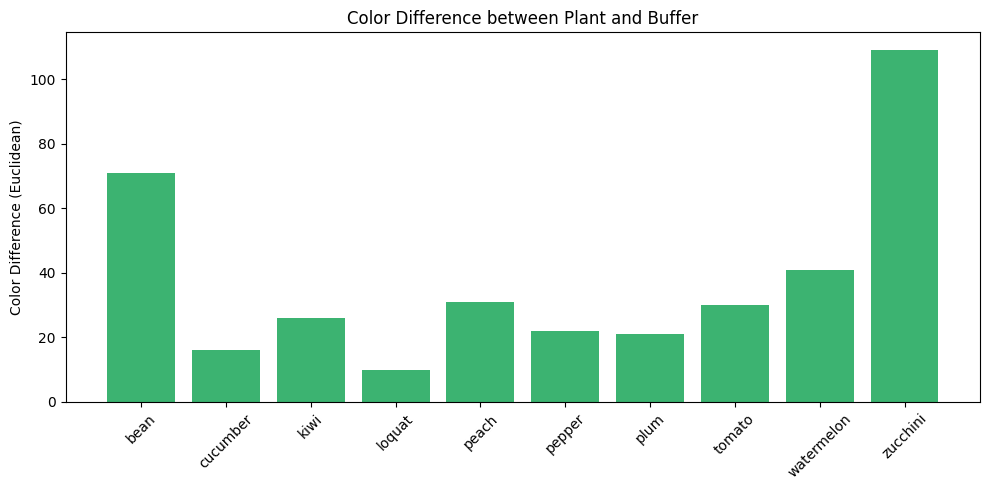

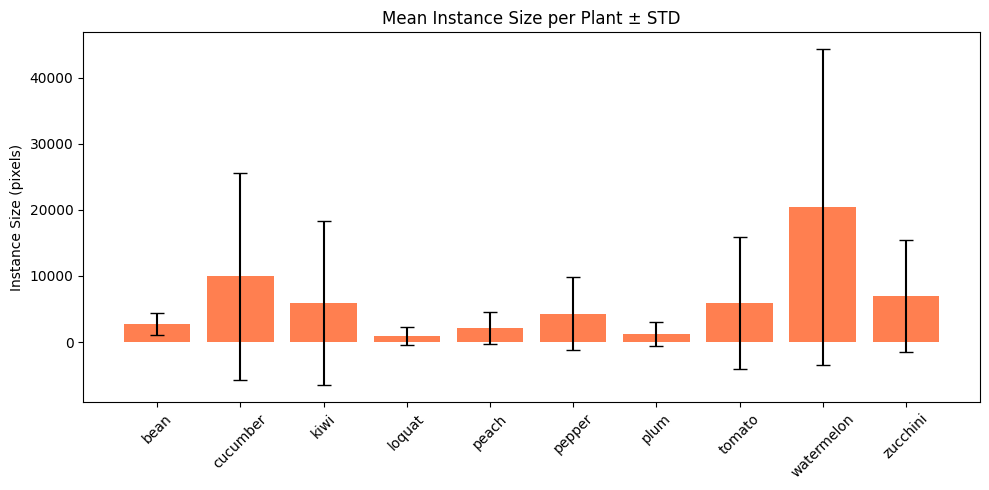

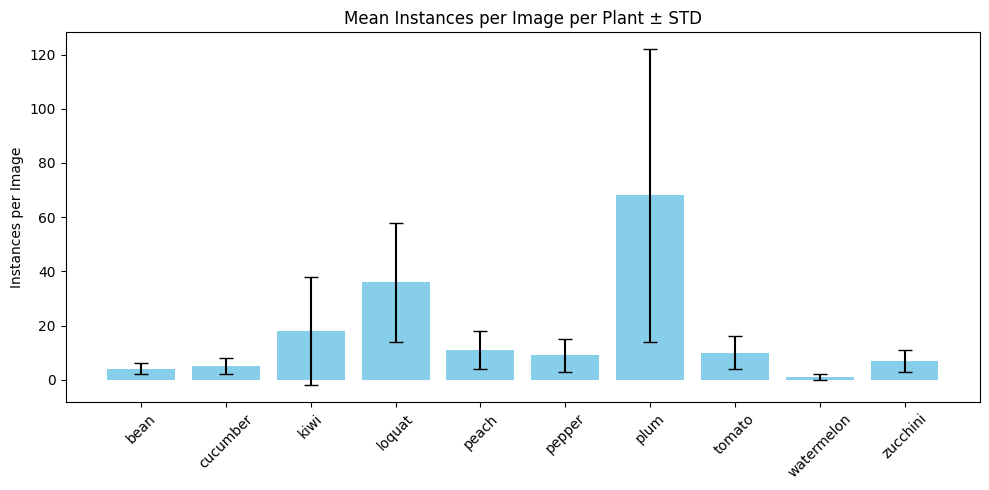

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os

# Create output folder
fig_dir = "plant_figures/B3"
os.makedirs(fig_dir, exist_ok=True)

# Convert dicts to lists for plotting
plants_list = plants
color_diff = [plant_diff_colors[p] for p in plants_list]

mean_instance_size = [plant_mean_instance_size[p] for p in plants_list]
std_instance_size = [plant_std_instance_size[p] for p in plants_list]

mean_instances_per_image = [plant_mean_instance_per_image[p] for p in plants_list]
std_instances_per_image = [plant_std_instance_per_image[p] for p in plants_list]

# ------------------------------
# 1. Color Difference Figure
# ------------------------------
plt.figure(figsize=(10, 5))
plt.bar(plants_list, color_diff, color='mediumseagreen')
plt.xticks(rotation=45)
plt.ylabel("Color Difference (Euclidean)")
plt.title("Color Difference between Plant and Buffer")
plt.tight_layout()
plt.savefig(f"{fig_dir}/color_difference.png", dpi=300, bbox_inches="tight")
plt.show()

# ------------------------------
# 2. Instance Size Figure
# ------------------------------
plt.figure(figsize=(10, 5))
plt.bar(plants_list, mean_instance_size, yerr=std_instance_size, color='coral', capsize=5)
plt.xticks(rotation=45)
plt.ylabel("Instance Size (pixels)")
plt.title("Mean Instance Size per Plant ± STD")
plt.tight_layout()
plt.savefig(f"{fig_dir}/instance_size.png", dpi=300, bbox_inches="tight")
plt.show()

# ------------------------------
# 3. Instances Per Image Figure
# ------------------------------
plt.figure(figsize=(10, 5))
plt.bar(plants_list, mean_instances_per_image, yerr=std_instances_per_image, color='skyblue', capsize=5)
plt.xticks(rotation=45)
plt.ylabel("Instances per Image")
plt.title("Mean Instances per Image per Plant ± STD")
plt.tight_layout()
plt.savefig(f"{fig_dir}/instances_per_image.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
import numpy as np
import os
from PIL import Image

def save_color_patch(color, size, path):
    """
    color: (R, G, B)
    size: int (n for nxn)
    path: output file path
    """
    patch = np.zeros((size, size, 3), dtype=np.uint8)
    patch[:, :] = color
    Image.fromarray(patch).save(path)

# Output directory
out_dir = "plant_color_patches/B3"
os.makedirs(out_dir, exist_ok=True)

n = 64  # nxn image size

for plant in plants:
    mean_color = plant_mean_colors[plant]
    buffer_color = plant_mean_buffer_colors[plant]

    save_color_patch(
        mean_color,
        n,
        os.path.join(out_dir, f"{plant}_mean_color.png")
    )

    save_color_patch(
        buffer_color,
        n,
        os.path.join(out_dir, f"{plant}_buffer_color.png")
    )

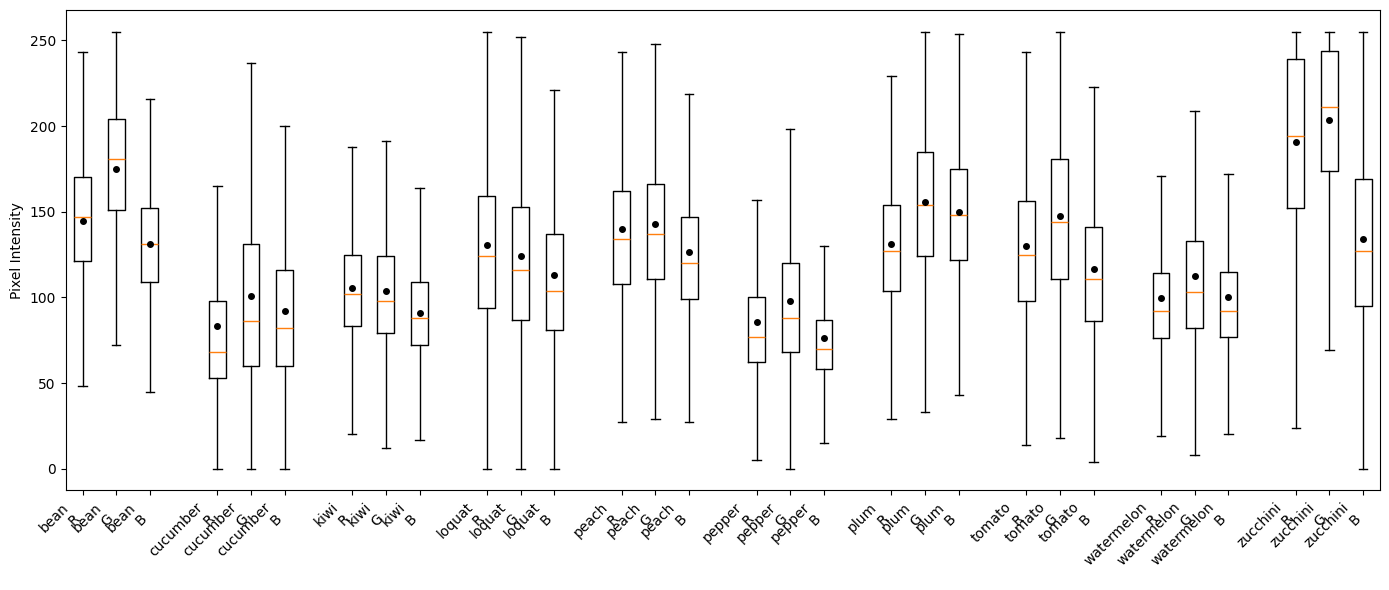

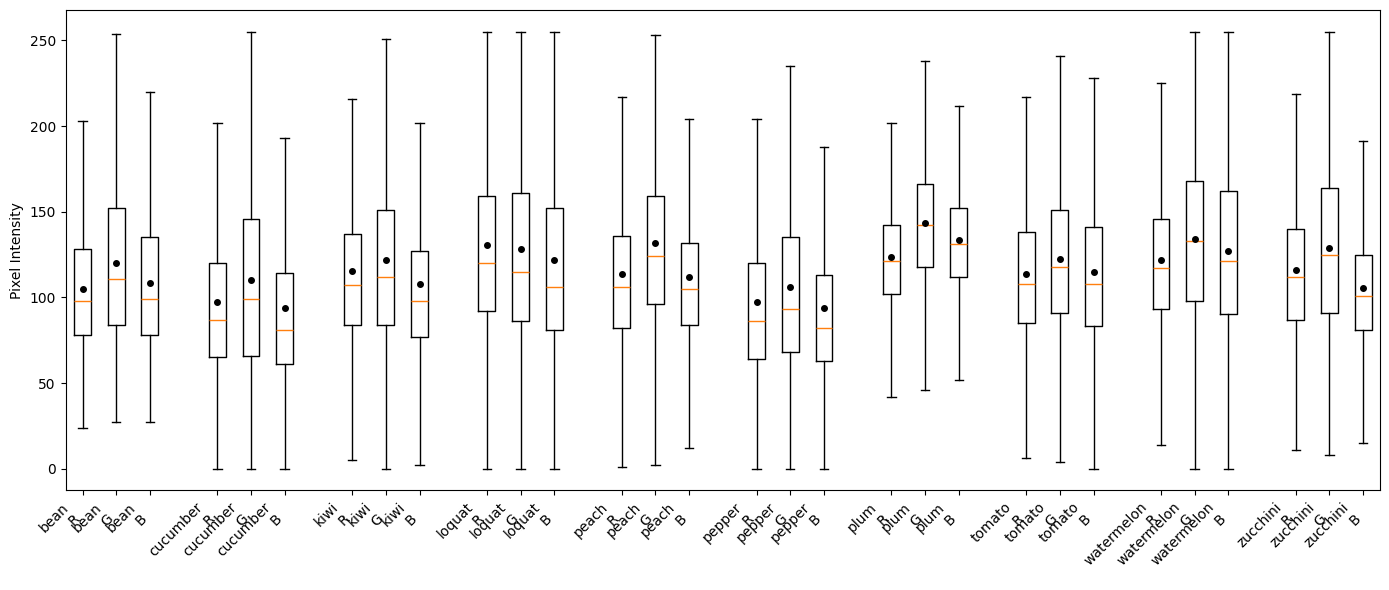

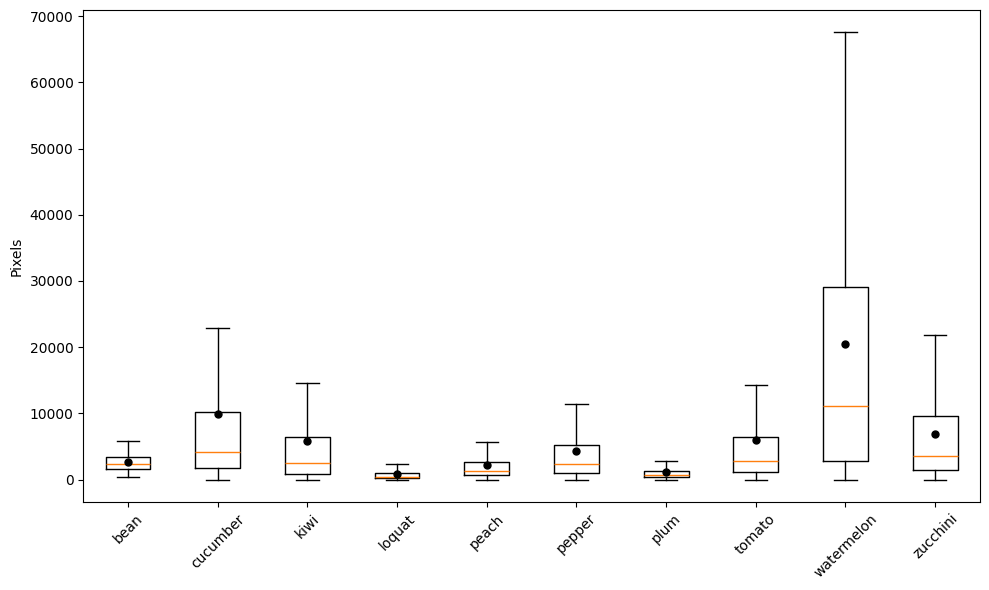

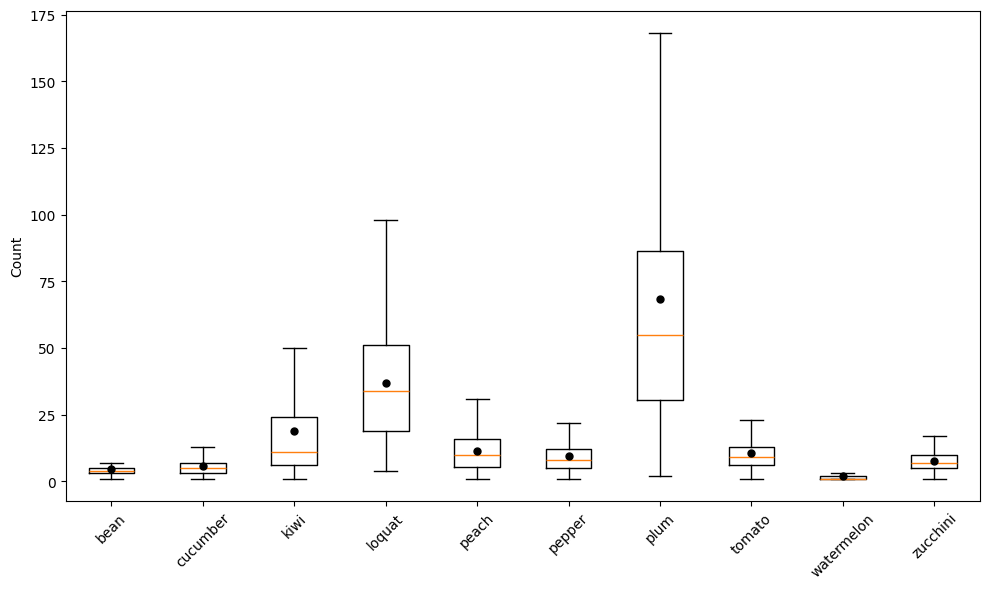

Missing columns for bean
Missing columns for cucumber
Missing columns for kiwi
Missing columns for loquat
Missing columns for peach
Missing columns for pepper
Missing columns for plum
Missing columns for tomato
Missing columns for watermelon
Missing columns for zucchini


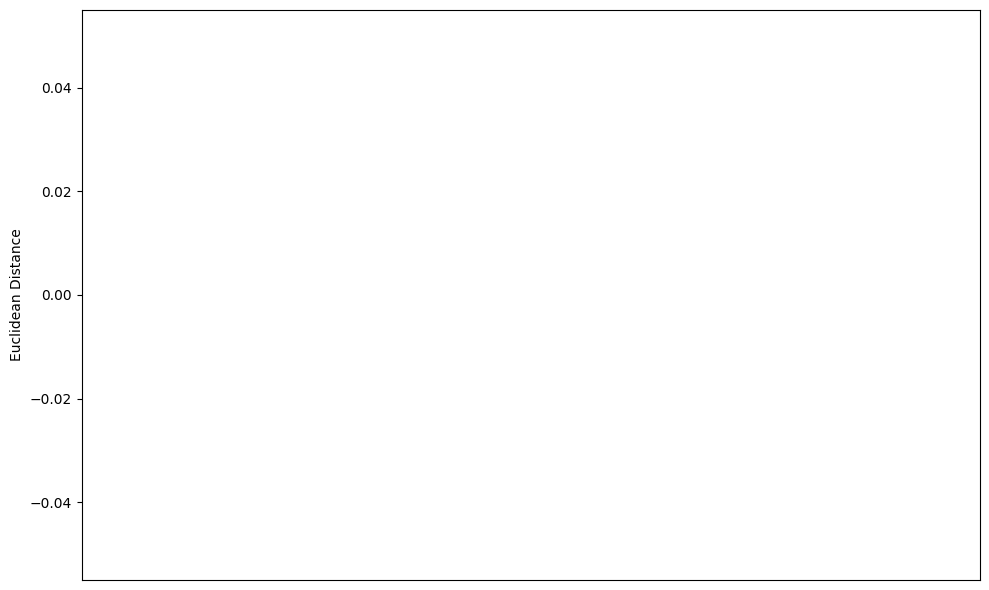

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

plants = ["bean", "cucumber", "kiwi", "loquat", "peach",
          "pepper", "plum", "tomato", "watermelon", "zucchini"]

csv_dir = "plant_csv_outputs/B3"
fig_dir = "boxplot_figures/B3"
os.makedirs(fig_dir, exist_ok=True)

In [ ]:
# Mean plant colors (RGB normalized to matplotlib 0–1 range)

plant_colors = {
    "bean":        (144/255, 175/255, 130/255),
    "cucumber":    (83/255, 100/255, 92/255),
    "kiwi":        (105/255, 103/255, 91/255),
    "loquat":      (130/255, 124/255, 112/255),
    "peach":       (139/255, 142/255, 126/255),
    "pepper":      (85/255, 98/255, 76/255),
    "plum":        (131/255, 155/255, 149/255),
    "tomato":      (129/255, 147/255, 116/255),
    "watermelon":  (99/255, 112/255, 100/255),
    "zucchini":    (190/255, 203/255, 134/255),
}

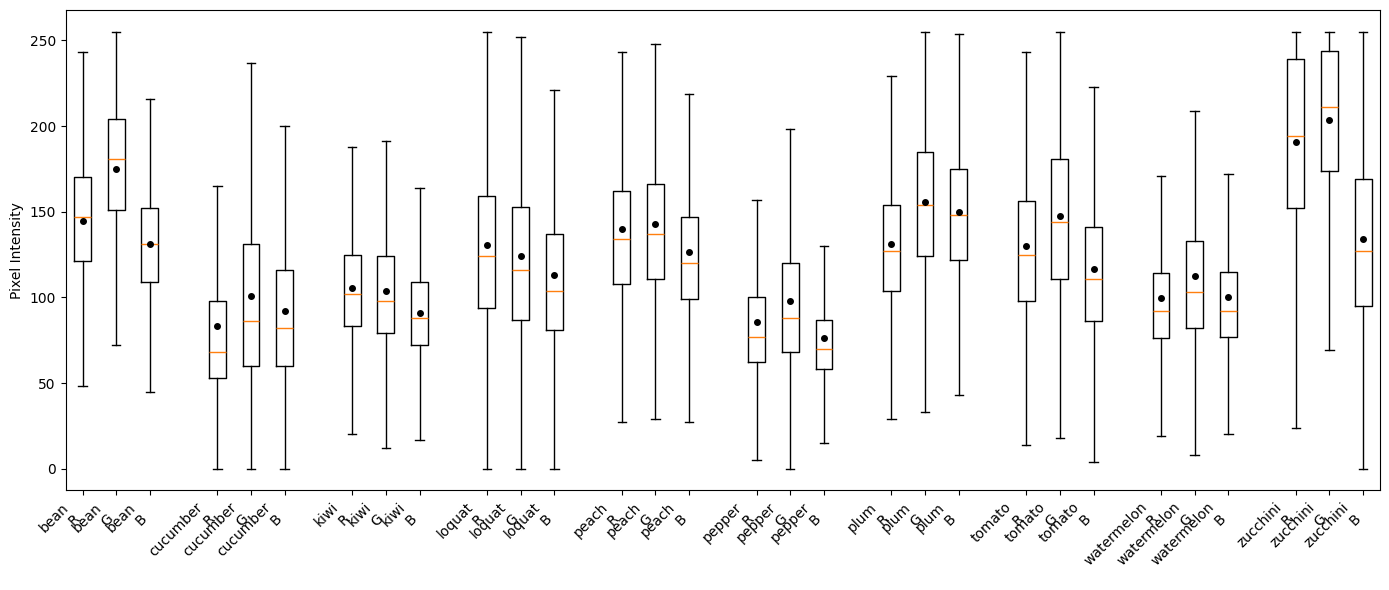

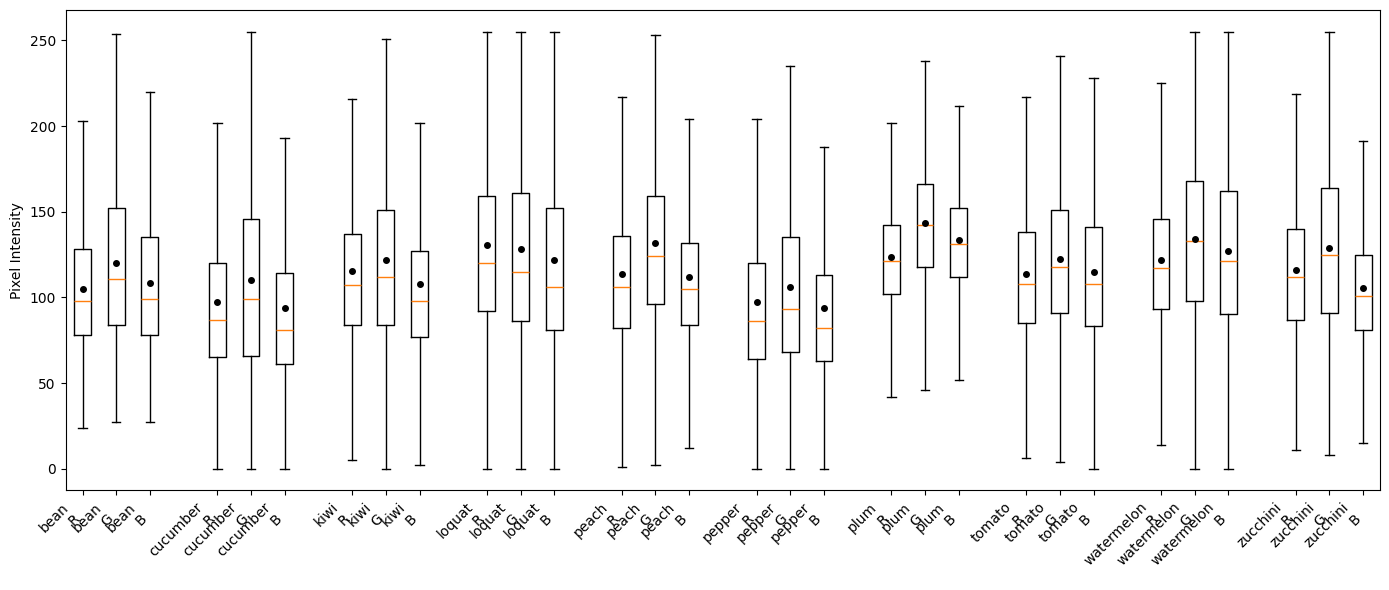

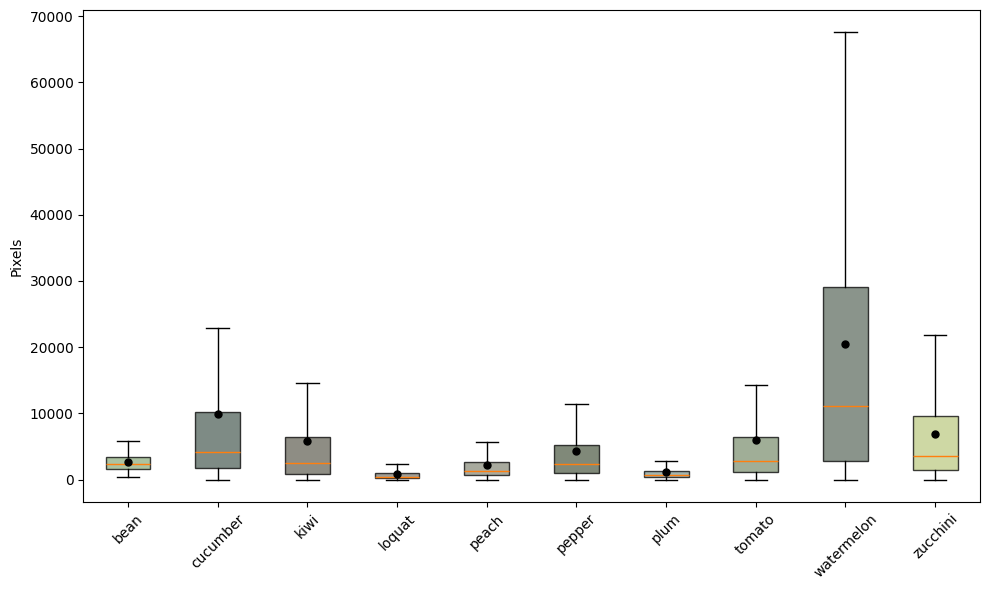

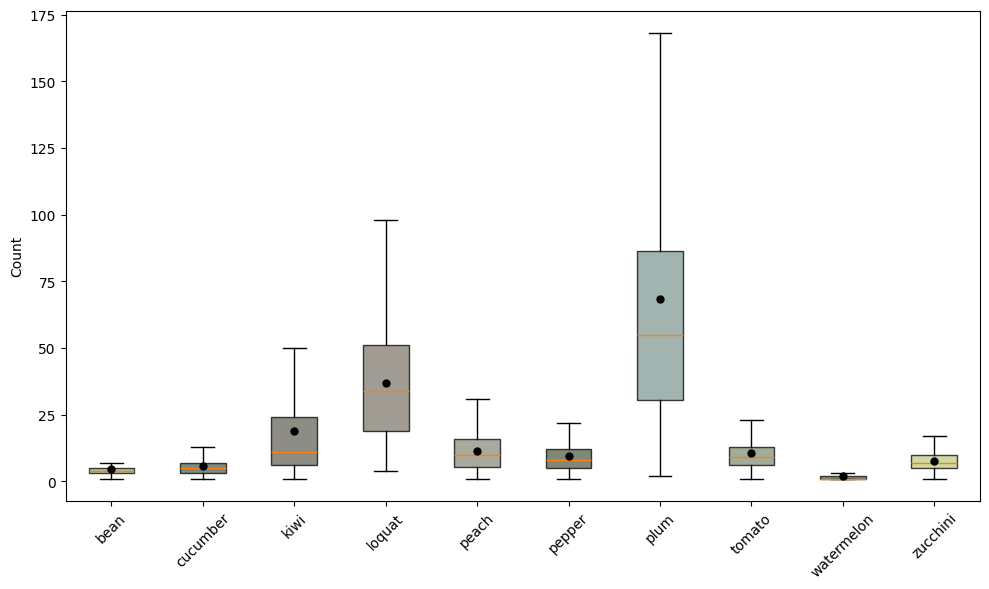

In [ ]:
# -------------------------------------------------
# Helper: grouped RGB boxplot (3 boxes per plant)
# -------------------------------------------------
def rgb_boxplot(file_suffix, title, save_name):
    data = []
    labels = []
    positions = []
    pos = 1

    for plant in plants:
        path = f"{csv_dir}/{plant}_{file_suffix}.csv"
        if not os.path.exists(path):
            continue

        df = pd.read_csv(path)

        # Expect columns B,G,R
        for ch in ["R", "G", "B"]:
            if ch in df.columns:
                data.append(df[ch].dropna())
                labels.append(f"{plant}\n{ch}")
                positions.append(pos)
                pos += 1

        pos += 1  # gap between plants

    plt.figure(figsize=(14, 6))
    plt.boxplot(
    data,
    positions=positions,
    showfliers=False,
    showmeans=True,
    meanprops={"marker": "o",
               "markerfacecolor": "black",
               "markeredgecolor": "black",
               "markersize": 4})
    plt.xticks(positions, labels, rotation=45, ha="right")
    #plt.title(title)
    plt.ylabel("Pixel Intensity")
    plt.tight_layout()
    plt.savefig(f"{fig_dir}/{save_name}", dpi=300, bbox_inches="tight")
    plt.show()


# -------------------------------------------------
# 1. Plant Color Boxplot (RGB)
# -------------------------------------------------
rgb_boxplot(
    file_suffix="all_pixels",
    title="Plant Color Distribution (RGB)",
    save_name="plant_color_boxplot.png"
)

# -------------------------------------------------
# 2. Buffer Color Boxplot (RGB)
# -------------------------------------------------
rgb_boxplot(
    file_suffix="buffer_all_pixels",
    title="Buffer Color Distribution (RGB)",
    save_name="buffer_color_boxplot.png"
)

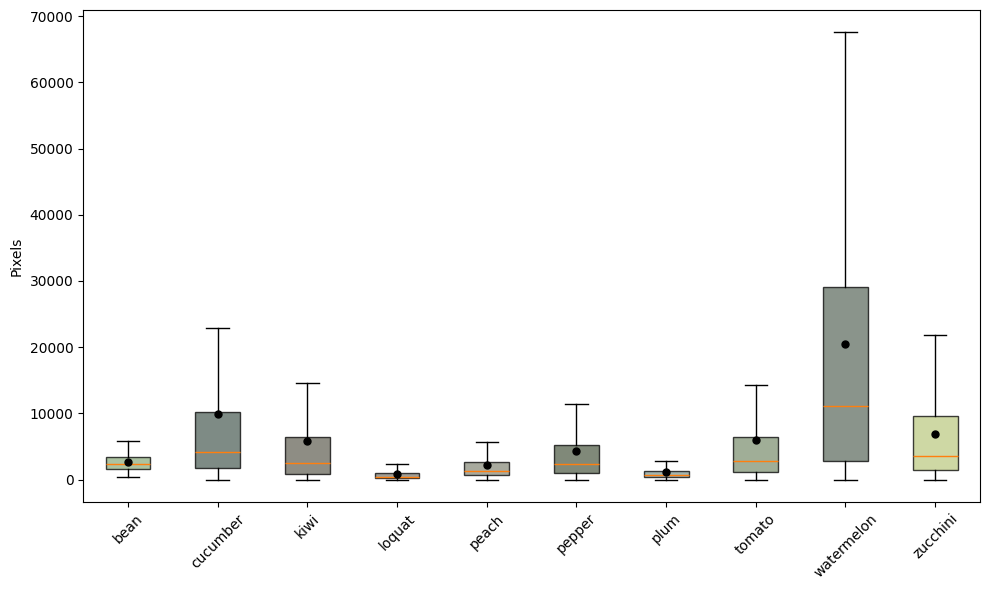

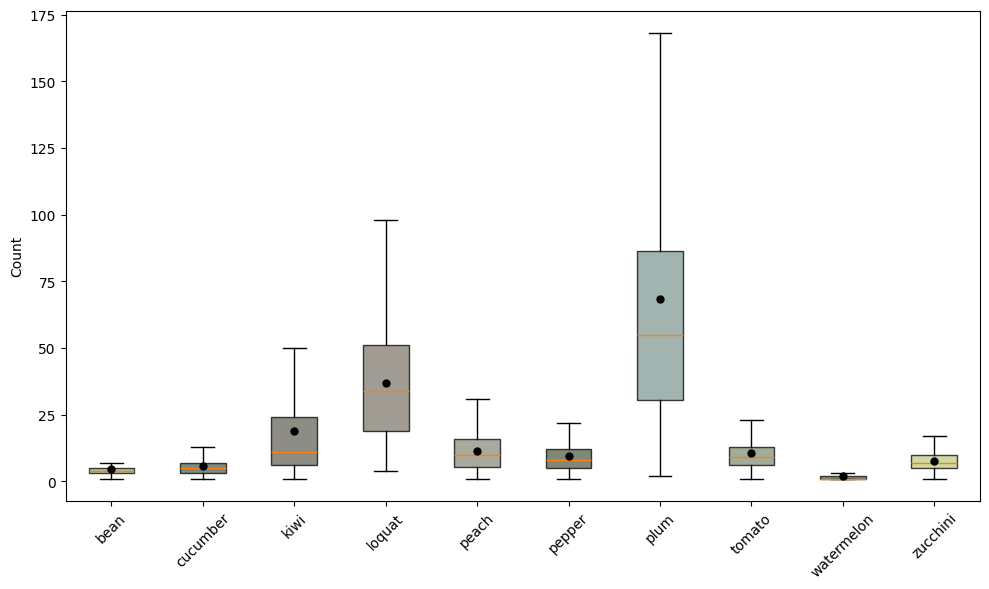

In [ ]:
# -------------------------------------------------
# Helper: single-value boxplots per plant
# -------------------------------------------------
def single_metric_boxplot(file_suffix, column_name, title, ylabel, save_name):
    data = []
    labels = []

    for plant in plants:
        path = f"{csv_dir}/{plant}_{file_suffix}.csv"
        if not os.path.exists(path):
            continue

        df = pd.read_csv(path)
        if column_name in df.columns:
            data.append(df[column_name].dropna())
            labels.append(plant)

    plt.figure(figsize=(10, 6))
    bp = plt.boxplot(
    data,
    showfliers=False,
    showmeans=True,
    patch_artist=True,
    meanprops={"marker": "o",
               "markerfacecolor": "black",
               "markeredgecolor": "black",
               "markersize": 5})
    
    for patch, plant in zip(bp["boxes"], labels):
        patch.set_facecolor(plant_colors.get(plant, (0.7, 0.7, 0.7)))
        patch.set_alpha(0.75)

    plt.xticks(range(1, len(labels) + 1), labels, rotation=45)
    #plt.title(title)
    plt.ylabel(ylabel)
    plt.tight_layout()
    plt.savefig(f"{fig_dir}/{save_name}", dpi=300, bbox_inches="tight")
    plt.show()


# -------------------------------------------------
# 3. Instance Size Boxplot
# -------------------------------------------------
single_metric_boxplot(
    file_suffix="pixel_sizes",
    column_name="pixel_size",
    title="Instance Size Distribution per Plant",
    ylabel="Pixels",
    save_name="instance_size_boxplot.png"
)

# -------------------------------------------------
# 4. Instances per Image Boxplot
# -------------------------------------------------
single_metric_boxplot(
    file_suffix="filenames_counts",
    column_name="instances_per_image",
    title="Instances per Image Distribution per Plant",
    ylabel="Count",
    save_name="instances_per_image_boxplot.png"
)

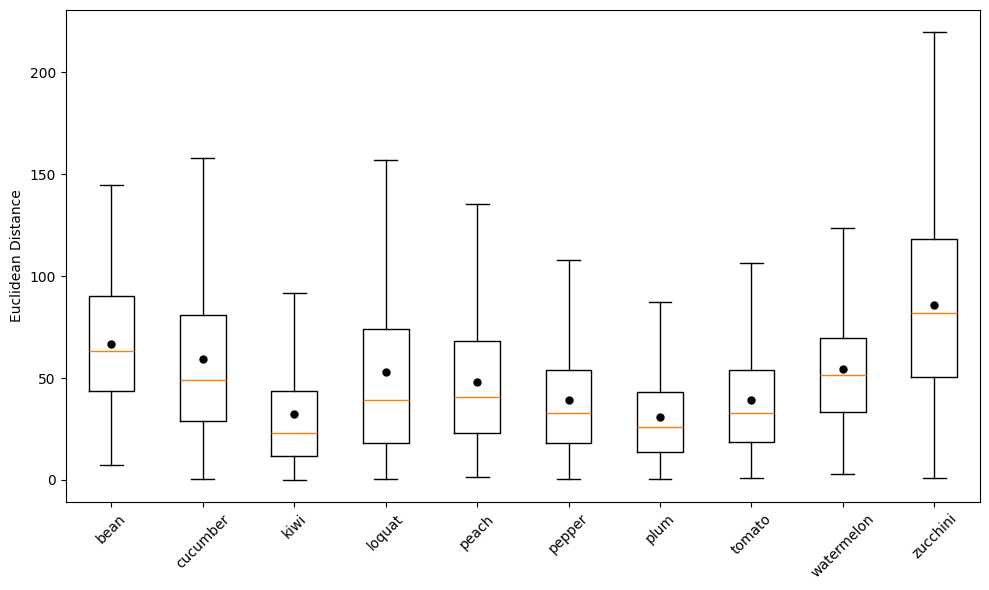

In [ ]:
# -------------------------------------------------
# 5. Color Difference Boxplot
# (computed from mean difference CSV or recomputed)
# -------------------------------------------------
color_diff_data = []
labels = []
output_csv = "plant_instance_color_differences.csv"

rows_out = []

for plant in plants:
    plant_rows = class_instances_df[class_instances_df["crop"] == plant]

    instance_diffs = []

    for _, row in plant_rows.iterrows():
        pixels = np.array(eval(row["pixels"]))
        buffer_pixels = np.array(eval(row["buffer_pixels"]))

        if len(pixels) == 0 or len(buffer_pixels) == 0:
            continue

        # mean colors (BGR)
        mean_p = pixels.mean(axis=0)
        mean_b = buffer_pixels.mean(axis=0)

        # convert to RGB if needed
        mean_p = mean_p[::-1]
        mean_b = mean_b[::-1]

        diff = np.linalg.norm(mean_p - mean_b)
        instance_diffs.append(diff)

        rows_out.append({
            "crop": plant,
            "filename": row["filename"],
            "instance": row["instance"],
            "area": row["area"],
            "color_diff": diff
        })

    if len(instance_diffs) > 0:
        color_diff_data.append(instance_diffs)
        labels.append(plant)

# Create dataframe
diff_df = pd.DataFrame(rows_out)

# Save CSV
diff_df.to_csv(output_csv, index=False)

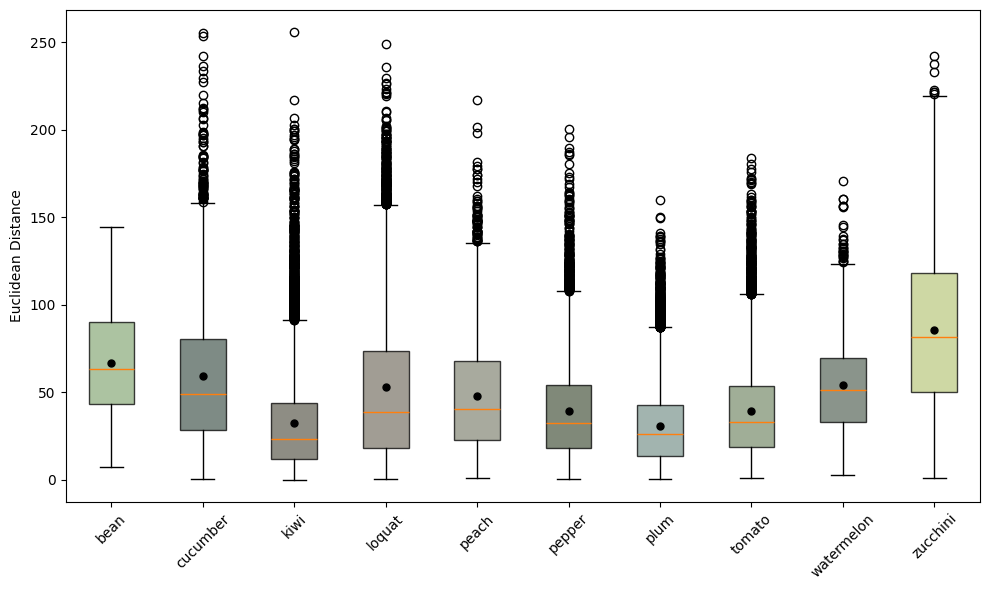

In [ ]:
plt.figure(figsize=(10, 6))
bp = plt.boxplot(
    color_diff_data,
    showmeans=True,
    patch_artist=True,
    meanprops={"marker": "o",
               "markerfacecolor": "black",
               "markeredgecolor": "black",
               "markersize": 5})

for patch, plant in zip(bp["boxes"], labels):
    patch.set_facecolor(plant_colors.get(plant, (0.7, 0.7, 0.7)))
    patch.set_alpha(0.75)
plt.xticks(range(1, len(labels) + 1), labels, rotation=45)
#plt.title("Color Difference Distribution per Plant")
plt.ylabel("Euclidean Distance")
plt.tight_layout()
plt.savefig(f"{fig_dir}/color_difference_boxplot.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
mean_per_plant = diff_df.groupby("crop")["color_diff"].mean().sort_values()

print("\nMean color difference per plant:")
for plant, val in mean_per_plant.items():
    print(f"{plant:12s}: {val:.2f}")


Mean color difference per plant:
plum        : 30.76
kiwi        : 32.40
tomato      : 39.24
pepper      : 39.28
peach       : 47.99
loquat      : 52.81
watermelon  : 54.36
cucumber    : 59.32
bean        : 66.65
zucchini    : 85.82


In [ ]:
stats_per_plant = diff_df.groupby("crop")["color_diff"].agg(["mean", "std", "count"])

print("\nColor difference stats per plant:")
print(stats_per_plant.round(2))


Color difference stats per plant:
             mean    std  count
crop                           
bean        66.65  31.07    223
cucumber    59.32  40.34   2997
kiwi        32.40  29.70  10096
loquat      52.81  44.82   6404
peach       47.99  31.62   6346
pepper      39.28  28.18   9053
plum        30.76  21.95  18514
tomato      39.24  26.81  11890
watermelon  54.36  28.22   1234
zucchini    85.82  44.78   9305


Saved → plant_per_image_coverage.csv

Per-image coverage stats (%):
             mean    std  count
crop                           
kiwi        5.339  5.089    538
plum        3.945  2.101    271
tomato      3.017  1.808   1128
cucumber    2.670  1.692    538
zucchini    2.563  1.202   1218
pepper      1.941  1.165    962
watermelon  1.866  1.314    651
loquat      1.613  0.797    174
peach       1.166  0.786    563
bean        0.593  0.298     49


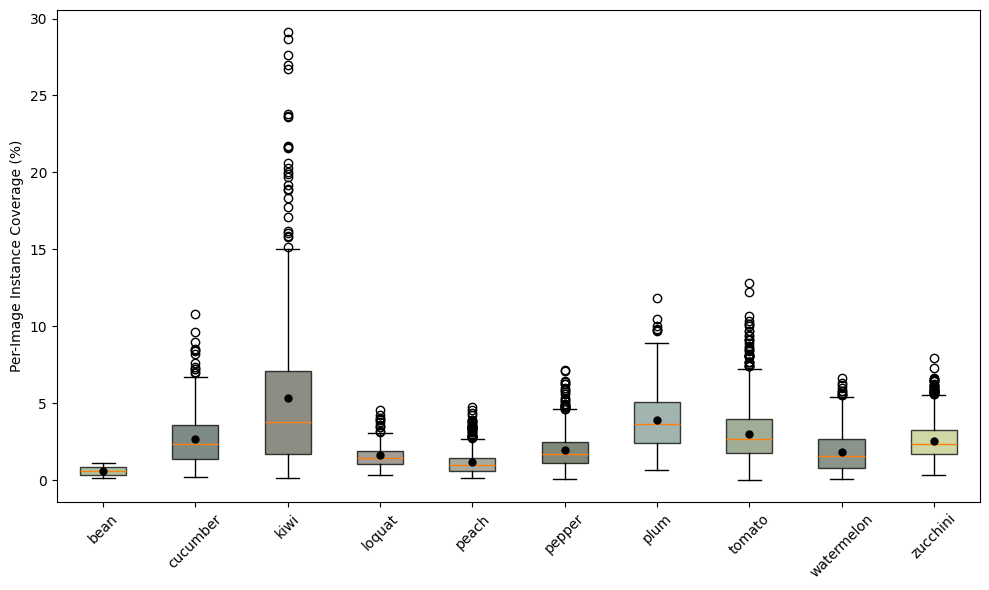

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

IMAGE_AREA = 1920 * 1080
coverage_csv = "plant_per_image_coverage.csv"

# -------------------------------------------------
# Compute per-image coverage
# -------------------------------------------------
rows_out = []

grouped = class_instances_df.groupby(["crop", "filename"])

for (plant, filename), group in grouped:
    total_instance_area = group["area"].sum()
    coverage_pct = (total_instance_area / IMAGE_AREA) * 100

    rows_out.append({
        "crop": plant,
        "filename": filename,
        "total_instance_area": total_instance_area,
        "coverage_pct": coverage_pct
    })

coverage_df = pd.DataFrame(rows_out)

# Save CSV
coverage_df.to_csv(coverage_csv, index=False)
print(f"Saved → {coverage_csv}")

# -------------------------------------------------
# Print mean coverage per plant
# -------------------------------------------------
coverage_stats = (
    coverage_df.groupby("crop")["coverage_pct"]
    .agg(["mean", "std", "count"])
    .sort_values("mean", ascending=False)
)

print("\nPer-image coverage stats (%):")
print(coverage_stats.round(3))

# -------------------------------------------------
# Boxplot per plant
# -------------------------------------------------
plants_sorted = coverage_df["crop"].unique()

box_data = []
labels = []

for plant in plants_sorted:
    vals = coverage_df.loc[coverage_df["crop"] == plant, "coverage_pct"].dropna()
    if len(vals) > 0:
        box_data.append(vals)
        labels.append(plant)

plt.figure(figsize=(10, 6))
bp = plt.boxplot(
    box_data,
    showmeans=True,
    patch_artist=True,
    meanprops={
        "marker": "o",
        "markerfacecolor": "black",
        "markeredgecolor": "black",
        "markersize": 5
    }
)
for patch, plant in zip(bp["boxes"], labels):
    patch.set_facecolor(plant_colors.get(plant, (0.7, 0.7, 0.7)))
    patch.set_alpha(0.75)

plt.xticks(range(1, len(labels) + 1), labels, rotation=45)
plt.ylabel("Per-Image Instance Coverage (%)")
plt.tight_layout()
plt.savefig(f"{fig_dir}/per_image_coverage.png", dpi=300, bbox_inches="tight")
plt.show()